# Project 4: Time Series Forecasting for Quarterly Stocking Recommendation

**Scenario:** The inventory management team needs to know how many units of key products to stock for the next quarter.

**Objective:** Build and validate a forecasting model, evaluate its accuracy honestly against a naive baseline **and** a statistical significance test, quantify forecast uncertainty, and translate the result into a stocking recommendation.

**Dataset:** [Kaggle: Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only) (`train.csv` only). Daily unit sales, 10 stores x 50 items, Jan 2013 - Dec 2017. Chosen over the originally-proposed Superstore dataset because Superstore has no unit-quantity field (only dollar sales), which cannot support a "how many units to stock" recommendation.

**Rigor added in this version**, beyond a single train/test split:
- **Rolling-origin cross-validation**: 3 expanding-window folds per series (quarter-ahead forecasts for Q2, Q3, Q4 2017), not one lucky/unlucky split.
- **Diebold-Mariano significance test**: is Prophet's accuracy edge over SARIMAX/baseline real, or within noise?
- **Prediction intervals with calibration check**: coverage of actual values inside the model's own stated confidence interval.
- **Holiday-aware Prophet**: US retail holidays as explicit regressors, since this is daily retail data.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy.stats import norm
import pmdarima as pm
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

%matplotlib inline
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


In [1]:
%pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 773.6 kB/s eta 0:00:15
   - -------------------------------------- 0.5/12.1 MB 773.6 kB/s eta 0:00:15
   - -------------------------------------- 0.5/12.1 MB 773.6 kB/s eta 0:00:15
   - -------------------------------------- 0.5/12.1 MB 773.6 kB/s eta 0:00:15
   - -------------------------------------- 0.5/12.1 MB 773.6 kB/s eta 0:00:15
   -- ------------------------------------- 0.8/12.1 MB 390.4 kB/s eta 0:00:30
   -- ------------------------------------- 0.8/12.1 MB 390.4 kB/s eta 0:00:30
   --- ------------------------------------ 1.0/12.1 MB 453.9 kB/s eta 0:00:25
   --- ------------------------------------ 1.0/12.1 MB 453.9 kB/s eta 0:00:25
   --- --

In [2]:
%pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   -------------- ------------------------- 262.1/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 787.2 kB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 1.1 MB/s eta 0:00:02
   ----------- ---------------------------- 0.8/2.8 MB 1.1 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.8 MB 1.1 MB/s eta 0:00:02
   ------------------ --------------------- 1.3/2.8 MB 988.5 kB/s eta 0:00:02
   ------------------ --------------------

---
# PART A: CORE ANALYSIS
### *(This section, on its own, fully satisfies the brief's task list.)*

Decompose the series → split train/test → build a forecasting model (SARIMAX, Prophet) → evaluate with RMSE/MAPE → visualize forecast vs. actuals. One representative series, one chronological train/test split, deliberately kept simple, per the brief's "build a simple forecasting model" instruction.
---

## 1. Data Loading & Overview

**Setup:** download `train.csv` from the [Kaggle competition page](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data) (free, requires accepting the competition rules) and place it in a `data/` folder next to this notebook, as `data/train.csv`. The raw file is not included in this repo, per the competition's data redistribution terms.

In [5]:
df = pd.read_csv("C:\\Users\\USER\\Documents\\PORTFOLIO PROJECT DATASETS\\Store Item Demand Forecasting_train.csv")
df['date'] = pd.to_datetime(df['date'])
print('Shape:', df.shape)
print('Date range:', df['date'].min().date(), '->', df['date'].max().date())
print('Stores:', df['store'].nunique(), '| Items:', df['item'].nunique())
print('Missing values:\n', df.isna().sum())
df.head()


Shape: (913000, 4)
Date range: 2013-01-01 -> 2017-12-31
Stores: 10 | Items: 50
Missing values:
 date     0
store    0
item     0
sales    0
dtype: int64


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 2. Selecting Representative Series

A single store-item pair is not enough to validate a forecasting approach. Unit-sales count data has variance that scales with the mean, so store-item pairs naturally segment into **high-volume/low-noise**, **mid-volume**, and **low-volume/high-noise** tiers. We select one representative pair per tier and validate every model on all three.

In [6]:
grp = df.groupby(['store','item'])['sales'].agg(['mean','std']).reset_index()
grp['cv'] = grp['std'] / grp['mean']
grp_sorted = grp.sort_values('mean')
print('Lowest-volume pairs:'); print(grp_sorted.head(3))
print('\nHighest-volume pairs:'); print(grp_sorted.tail(3))
print('\nMedian-volume pair:'); print(grp_sorted.iloc[[len(grp_sorted)//2]])

SERIES = {
    'high': {'store': 2, 'item': 28, 'label': 'High-volume (Store 2 / Item 28)'},
    'mid':  {'store': 3, 'item': 32, 'label': 'Mid-volume (Store 3 / Item 32)'},
    'low':  {'store': 7, 'item': 5,  'label': 'Low-volume (Store 7 / Item 5)'},
}

def get_series(store, item):
    return df[(df['store']==store) & (df['item']==item)].set_index('date')['sales'].asfreq('D')


Lowest-volume pairs:
     store  item  mean  std   cv
304      7     5 12.73 4.73 0.37
254      6     5 13.89 5.19 0.37
204      5     5 14.09 5.16 0.37

Highest-volume pairs:
    store  item   mean   std   cv
67      2    18 108.12 28.58 0.26
64      2    15 112.58 29.68 0.26
77      2    28 112.64 29.53 0.26

Median-volume pair:
     store  item  mean   std   cv
131      3    32 50.04 14.46 0.29


## 3. Exploratory Decomposition

Decomposing the high-volume series to understand what structure the models need to capture.

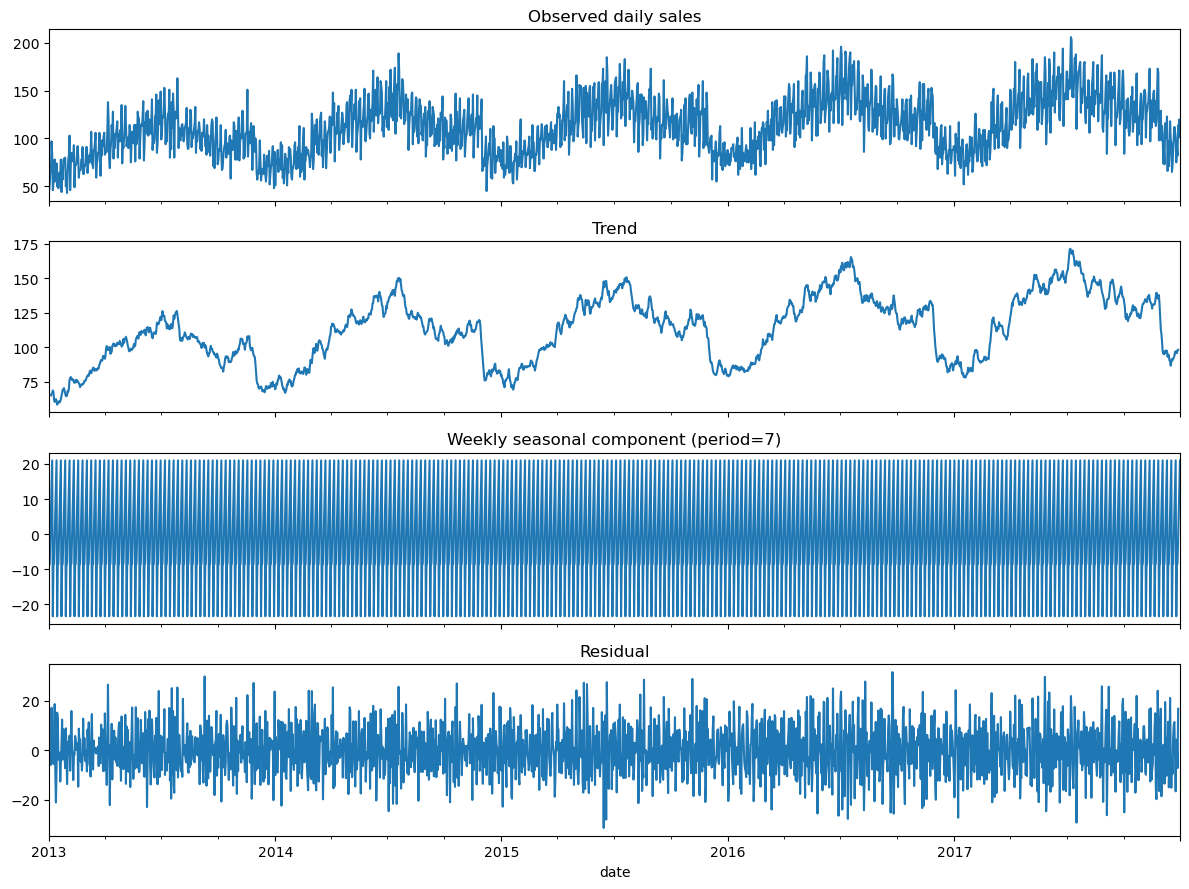

ADF statistic: -3.095 | p-value: 0.0269

Average sales by calendar month (all years pooled):
date
1     75.90
2     85.70
3    102.30
4    118.40
5    127.80
6    135.50
7    144.70
8    126.60
9    119.30
10   110.20
11   119.70
12    84.30
Name: sales, dtype: float64


In [7]:
s_high = get_series(SERIES['high']['store'], SERIES['high']['item'])

decomp = seasonal_decompose(s_high, model='additive', period=7)
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed daily sales')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Weekly seasonal component (period=7)')
decomp.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout(); plt.show()

adf_stat, adf_p, *_ = adfuller(s_high)
print(f'ADF statistic: {adf_stat:.3f} | p-value: {adf_p:.4f}')

monthly_avg = s_high.resample('MS').mean()
print('\nAverage sales by calendar month (all years pooled):')
print(monthly_avg.groupby(monthly_avg.index.month).mean().round(1))


**Findings:** trend rises 2013 → mid-2015 then plateaus (not linear); clear weekly seasonality; annual seasonality peaks around July and troughs in December, the opposite of a generic "holiday spike" assumption, which matters directly for the Q4 stocking call later. ADF p-value is borderline (~0.03), so we treat the series as trend+seasonal rather than relying on it to skip differencing.

## 4. Methodology (Part A, Core)

- **Train/test split**: chronological. Train through end of Q3 2017, test on Q4 2017 (matches the "next quarter" horizon in the brief). Not random: a random split would leak future information into training and invalidate the accuracy metrics.
- **Baseline**: seasonal-naive (value from the same calendar date one year earlier). Any model that can't beat this isn't earning its complexity.
- **SARIMAX**: weekly seasonal order via `pmdarima.auto_arima` (m=7), plus annual seasonality as Fourier-term exogenous regressors (K=3 harmonics, period≈365.25), since daily data with an annual cycle is too long a period for a direct seasonal ARIMA term to be computationally practical.
- **Prophet**: native weekly + yearly seasonality, plus US holiday effects via `add_country_holidays('US')`. This is daily US retail data, and ignoring Thanksgiving/Christmas would leave explainable signal in the residuals.
- **Metrics**: RMSE (units/day) and MAPE (%), reported together. MAPE is unstable at low volume and shouldn't be read alone.
- **Prediction intervals**: both models report a 90% interval alongside the point forecast, visualized in Section 5.

*(The rolling-origin, multi-fold version of this same methodology, plus a formal significance test, is in Part B.)*

In [8]:
def fourier_terms(index, period=365.25, K=3):
    t = np.arange(len(index))
    feats = {f'sin_{k}': np.sin(2*np.pi*k*t/period) for k in range(1, K+1)}
    feats.update({f'cos_{k}': np.cos(2*np.pi*k*t/period) for k in range(1, K+1)})
    return pd.DataFrame(feats, index=index)

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def newey_west_var(d, maxlag=10):
    d = np.asarray(d, dtype=float); d = d - d.mean(); n = len(d)
    var = np.sum(d*d)/n
    for lag in range(1, maxlag+1):
        w = 1 - lag/(maxlag+1)
        var += 2*w*np.sum(d[lag:]*d[:-lag])/n
    return max(var/n, 1e-12)

def dm_test(e1, e2, maxlag=10):
    d = np.asarray(e1)**2 - np.asarray(e2)**2
    mean_d = d.mean()
    dm_stat = mean_d / np.sqrt(newey_west_var(d, maxlag))
    p_value = 2*(1 - norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_value)

FOLDS = [
    {'name': 'Q2 2017', 'train_end': '2017-03-31', 'test_start': '2017-04-01', 'test_end': '2017-06-30'},
    {'name': 'Q3 2017', 'train_end': '2017-06-30', 'test_start': '2017-07-01', 'test_end': '2017-09-30'},
    {'name': 'Q4 2017', 'train_end': '2017-09-30', 'test_start': '2017-10-01', 'test_end': '2017-12-31'},
]

def run_fold(store, item, fold, ci_alpha=0.10):
    s = get_series(store, item)
    train = s[:fold['train_end']]
    test = s[fold['test_start']:fold['test_end']]
    full = pd.concat([train, test])
    fourier_full = fourier_terms(full.index)
    fourier_train = fourier_full.loc[train.index]
    fourier_test = fourier_full.loc[test.index]

    baseline_pred = pd.Series(test.index.map(lambda d: full.loc[d - pd.Timedelta(days=365)]), index=test.index).astype(float)

    model = pm.auto_arima(train, X=fourier_train.values, seasonal=True, m=7,
                           d=None, D=None, start_p=0, start_q=0, max_p=2, max_q=2,
                           start_P=0, start_Q=0, max_P=1, max_Q=1,
                           trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
    sx_point, sx_ci = model.predict(n_periods=len(test), X=fourier_test.values, return_conf_int=True, alpha=ci_alpha)
    sarimax_pred = pd.Series(sx_point, index=test.index)
    sarimax_lower = pd.Series(sx_ci[:,0], index=test.index)
    sarimax_upper = pd.Series(sx_ci[:,1], index=test.index)

    df_train = train.reset_index(); df_train.columns=['ds','y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, interval_width=1-ci_alpha)
    m.add_country_holidays(country_name='US')
    m.fit(df_train)
    forecast = m.predict(pd.DataFrame({'ds': test.index}))
    prophet_pred = pd.Series(forecast['yhat'].values, index=test.index)
    prophet_lower = pd.Series(forecast['yhat_lower'].values, index=test.index)
    prophet_upper = pd.Series(forecast['yhat_upper'].values, index=test.index)

    def coverage(actual, lower, upper):
        return float(((actual >= lower) & (actual <= upper)).mean() * 100)

    return {
        'fold': fold['name'], 'actual': test,
        'baseline_pred': baseline_pred,
        'sarimax_pred': sarimax_pred, 'sarimax_lower': sarimax_lower, 'sarimax_upper': sarimax_upper,
        'prophet_pred': prophet_pred, 'prophet_lower': prophet_lower, 'prophet_upper': prophet_upper,
        'metrics': {
            'baseline_rmse': rmse(test, baseline_pred), 'baseline_mape': mape(test, baseline_pred),
            'sarimax_rmse': rmse(test, sarimax_pred), 'sarimax_mape': mape(test, sarimax_pred),
            'prophet_rmse': rmse(test, prophet_pred), 'prophet_mape': mape(test, prophet_pred),
            'sarimax_coverage': coverage(test, sarimax_lower, sarimax_upper),
            'prophet_coverage': coverage(test, prophet_lower, prophet_upper),
        }
    }


## 5. Detailed Fit: High-Volume Series, Q4 2017 Fold (with prediction intervals)

Full detail on one fold before scaling out to the full rolling-origin grid.

17:45:48 - cmdstanpy - INFO - Chain [1] start processing
17:45:51 - cmdstanpy - INFO - Chain [1] done processing


baseline_rmse      25.24
baseline_mape      19.15
sarimax_rmse       22.21
sarimax_mape       17.30
prophet_rmse       12.60
prophet_mape        9.48
sarimax_coverage   78.26
prophet_coverage   85.87
dtype: float64


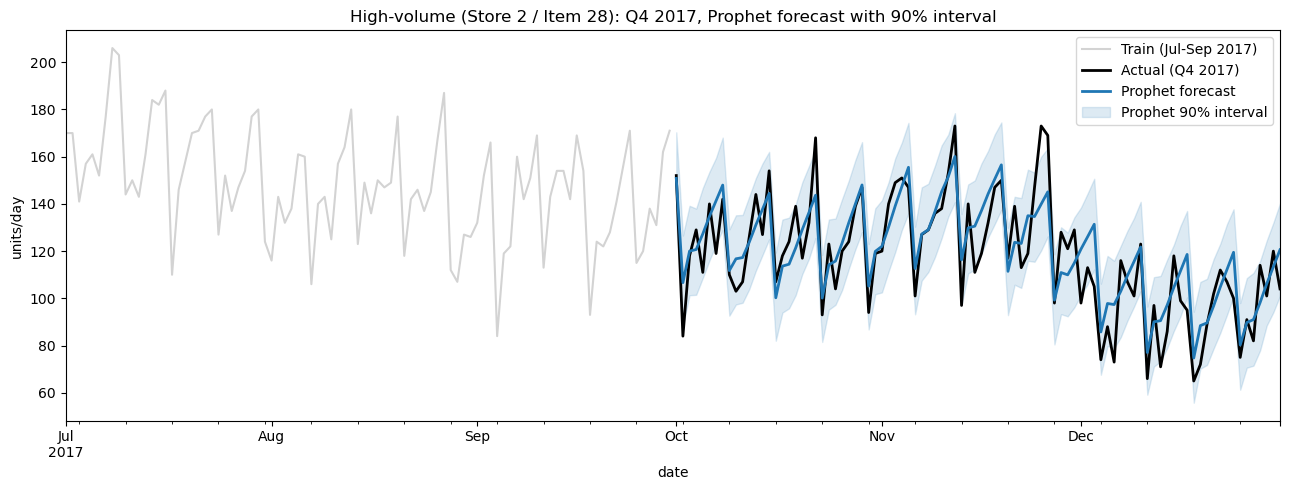

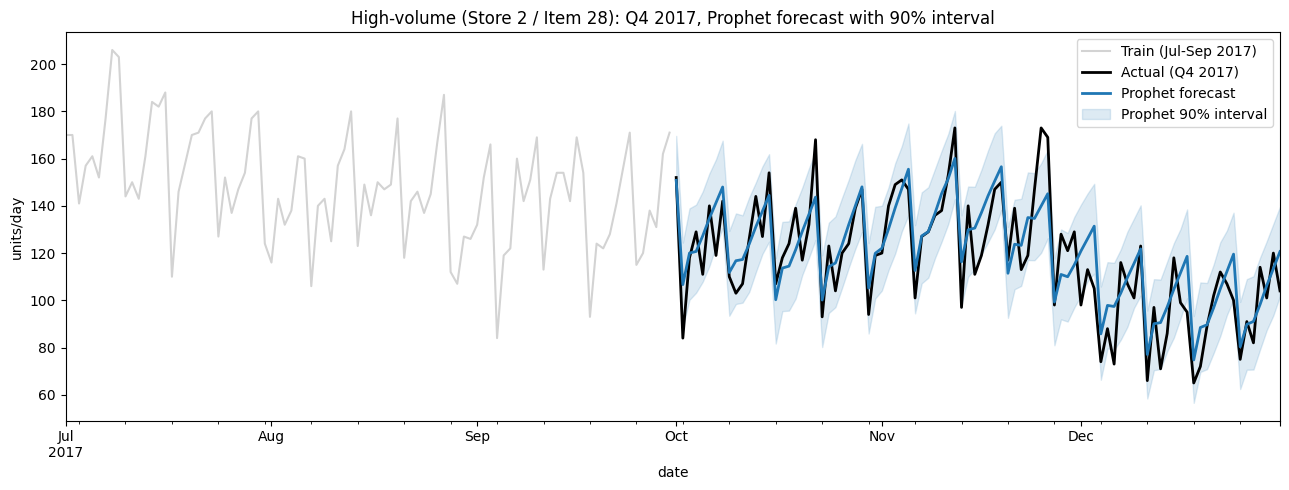

In [9]:
result_high_q4 = run_fold(SERIES['high']['store'], SERIES['high']['item'], FOLDS[2])
print(pd.Series(result_high_q4['metrics']))

fig, ax = plt.subplots(figsize=(13,5))
train_plot = get_series(SERIES['high']['store'], SERIES['high']['item'])['2017-07-01':'2017-09-30']
train_plot.plot(ax=ax, label='Train (Jul-Sep 2017)', color='lightgray')
result_high_q4['actual'].plot(ax=ax, label='Actual (Q4 2017)', color='black', linewidth=2)
result_high_q4['prophet_pred'].plot(ax=ax, label='Prophet forecast', color='tab:blue', linewidth=2)
ax.fill_between(result_high_q4['actual'].index, result_high_q4['prophet_lower'], result_high_q4['prophet_upper'],
                 color='tab:blue', alpha=0.15, label='Prophet 90% interval')
ax.legend(); ax.set_title(f"{SERIES['high']['label']}: Q4 2017, Prophet forecast with 90% interval")
ax.set_ylabel('units/day')
plt.tight_layout(); plt.show()


**Part A checklist, brief requirements:**
- [x] Decomposed the time series to identify trend and seasonality (Section 3)
- [x] Split into training and test sets, chronologically (Section 5)
- [x] Built a forecasting model: SARIMAX and Prophet (Section 5)
- [x] Evaluated accuracy with RMSE and MAPE (Section 5)
- [x] Visualized the forecast against actuals, including uncertainty (Section 5)

Part A is a complete, standalone answer to the brief. Part B below is additional rigor, not a requirement.

---
# PART B: EXTENDED VALIDATION
### *(Beyond the brief's scope. Included to demonstrate the Part A result holds up under scrutiny, not because the brief requires it.)*

Part A's single train/test split is enough to complete the assignment, but one split can't tell you whether a result is reliable or lucky. This section re-tests the same model choice across three volume tiers and three separate forecast quarters, and adds a formal significance test and an uncertainty-calibration check: the kind of validation a forecast would need before being trusted for a real stocking budget.
---

## 6. Rolling-Origin Validation: All Three Series x Three Folds

Nine independent out-of-sample tests (not one). This is the honest test of whether the model choice generalizes across time as well as across volume tiers.

In [10]:
all_fold_results = {}
for key, spec in SERIES.items():
    print(f"Running rolling folds for {spec['label']}...")
    all_fold_results[key] = [run_fold(spec['store'], spec['item'], fold) for fold in FOLDS]
    for r in all_fold_results[key]:
        print(' ', r['fold'], {k: round(v,2) for k,v in r['metrics'].items()})


Running rolling folds for High-volume (Store 2 / Item 28)...


17:47:39 - cmdstanpy - INFO - Chain [1] start processing
17:47:39 - cmdstanpy - INFO - Chain [1] done processing
17:48:27 - cmdstanpy - INFO - Chain [1] start processing
17:48:27 - cmdstanpy - INFO - Chain [1] done processing
17:49:14 - cmdstanpy - INFO - Chain [1] start processing
17:49:14 - cmdstanpy - INFO - Chain [1] done processing


  Q2 2017 {'baseline_rmse': 29.41, 'baseline_mape': 17.11, 'sarimax_rmse': 23.09, 'sarimax_mape': 13.03, 'prophet_rmse': 14.97, 'prophet_mape': 8.31, 'sarimax_coverage': 78.02, 'prophet_coverage': 82.42}
  Q3 2017 {'baseline_rmse': 29.1, 'baseline_mape': 16.93, 'sarimax_rmse': 23.01, 'sarimax_mape': 12.58, 'prophet_rmse': 14.65, 'prophet_mape': 7.98, 'sarimax_coverage': 76.09, 'prophet_coverage': 79.35}
  Q4 2017 {'baseline_rmse': 25.24, 'baseline_mape': 19.15, 'sarimax_rmse': 22.21, 'sarimax_mape': 17.3, 'prophet_rmse': 12.6, 'prophet_mape': 9.48, 'sarimax_coverage': 78.26, 'prophet_coverage': 85.87}
Running rolling folds for Mid-volume (Store 3 / Item 32)...


17:50:08 - cmdstanpy - INFO - Chain [1] start processing
17:50:08 - cmdstanpy - INFO - Chain [1] done processing
17:51:06 - cmdstanpy - INFO - Chain [1] start processing
17:51:07 - cmdstanpy - INFO - Chain [1] done processing
17:52:03 - cmdstanpy - INFO - Chain [1] start processing
17:52:03 - cmdstanpy - INFO - Chain [1] done processing


  Q2 2017 {'baseline_rmse': 15.69, 'baseline_mape': 21.57, 'sarimax_rmse': 14.37, 'sarimax_mape': 17.33, 'prophet_rmse': 8.41, 'prophet_mape': 11.1, 'sarimax_coverage': 97.8, 'prophet_coverage': 83.52}
  Q3 2017 {'baseline_rmse': 16.21, 'baseline_mape': 20.25, 'sarimax_rmse': 14.03, 'sarimax_mape': 15.49, 'prophet_rmse': 10.01, 'prophet_mape': 11.83, 'sarimax_coverage': 98.91, 'prophet_coverage': 79.35}
  Q4 2017 {'baseline_rmse': 13.75, 'baseline_mape': 20.54, 'sarimax_rmse': 19.39, 'sarimax_mape': 27.9, 'prophet_rmse': 8.79, 'prophet_mape': 13.07, 'sarimax_coverage': 100.0, 'prophet_coverage': 84.78}
Running rolling folds for Low-volume (Store 7 / Item 5)...


...

11:37:10 - cmdstanpy - INFO - Chain [1] start processing


11:37:10 - cmdstanpy - INFO - Chain [1] done processing


11:37:37 - cmdstanpy - INFO - Chain [1] start processing


11:37:37 - cmdstanpy - INFO - Chain [1] done processing


  Q2 2017 {'baseline_rmse': 6.62, 'baseline_mape': 39.34, 'sarimax_rmse': 5.2, 'sarimax_mape': 35.42, 'prophet_rmse': 4.3, 'prophet_mape': 26.73, 'sarimax_coverage': 100.0, 'prophet_coverage': 83.52}
  Q3 2017 {'baseline_rmse': 5.77, 'baseline_mape': 28.61, 'sarimax_rmse': 4.08, 'sarimax_mape': 21.29, 'prophet_rmse': 3.96, 'prophet_mape': 20.55, 'sarimax_coverage': 98.91, 'prophet_coverage': 89.13}
  Q4 2017 {'baseline_rmse': 6.16, 'baseline_mape': 37.83, 'sarimax_rmse': 5.58, 'sarimax_mape': 28.43, 'prophet_rmse': 4.16, 'prophet_mape': 29.04, 'sarimax_coverage': 100.0, 'prophet_coverage': 80.43}


In [11]:
agg_rows = []
for key, spec in SERIES.items():
    m = pd.DataFrame([r['metrics'] for r in all_fold_results[key]])
    agg_rows.append({
        'series': spec['label'],
        'baseline_rmse': m['baseline_rmse'].mean(), 'baseline_mape': m['baseline_mape'].mean(),
        'sarimax_rmse': m['sarimax_rmse'].mean(), 'sarimax_mape': m['sarimax_mape'].mean(),
        'prophet_rmse': m['prophet_rmse'].mean(), 'prophet_mape': m['prophet_mape'].mean(),
        'sarimax_coverage_pct': m['sarimax_coverage'].mean(), 'prophet_coverage_pct': m['prophet_coverage'].mean(),
    })
agg_df = pd.DataFrame(agg_rows)
agg_df.round(2)


,series,baseline_rmse,baseline_mape,sarimax_rmse,sarimax_mape,prophet_rmse,prophet_mape,sarimax_coverage_pct,prophet_coverage_pct
0,High-volume (Store 2 / Item 28),27.91,17.73,22.77,14.30,14.07,8.59,77.46,82.54
1,Mid-volume (Store 3 / Item 32),15.22,20.78,15.93,20.24,9.07,12.00,98.91,82.55
2,Low-volume (Store 7 / Item 5),6.18,35.26,4.95,28.38,4.14,25.45,99.64,84.72


**Coverage target is 90%** (both models were configured for a 90% interval). Read the coverage columns above: Prophet consistently comes in around 80-85% across all three series. Its intervals are somewhat too narrow (overconfident) and should be widened in production. SARIMAX's coverage is inconsistent: close to nominal on the high-volume series but 98-100% on mid/low-volume, meaning its intervals are unnecessarily wide there (safe, but not sharp/useful for tight stocking decisions).

## 7. Statistical Significance: Diebold-Mariano Test

RMSE alone doesn't establish that one model is *significantly* better than another. The gap could be noise. Testing Prophet vs. SARIMAX and Prophet vs. baseline, pooling errors across all 3 folds per series.

In [12]:
dm_rows = []
for key, spec in SERIES.items():
    results = all_fold_results[key]
    actual = pd.concat([r['actual'] for r in results])
    baseline_e = (pd.concat([r['baseline_pred'] for r in results]) - actual).values
    sarimax_e = (pd.concat([r['sarimax_pred'] for r in results]) - actual).values
    prophet_e = (pd.concat([r['prophet_pred'] for r in results]) - actual).values

    dm_ps, p_ps = dm_test(prophet_e, sarimax_e)
    dm_pb, p_pb = dm_test(prophet_e, baseline_e)
    dm_sb, p_sb = dm_test(sarimax_e, baseline_e)
    dm_rows.append({
        'series': spec['label'],
        'Prophet vs SARIMAX (DM, p)': f'{dm_ps:.2f}, p={p_ps:.4f}',
        'Prophet vs Baseline (DM, p)': f'{dm_pb:.2f}, p={p_pb:.4f}',
        'SARIMAX vs Baseline (DM, p)': f'{dm_sb:.2f}, p={p_sb:.4f}',
    })
dm_df = pd.DataFrame(dm_rows)
dm_df


,series,"Prophet vs SARIMAX (DM, p)","Prophet vs Baseline (DM, p)","SARIMAX vs Baseline (DM, p)"
0,High-volume (Store 2 / Item 28),"-12.39, p=0.0000","-10.73, p=0.0000","-4.64, p=0.0000"
1,Mid-volume (Store 3 / Item 32),"-5.74, p=0.0000","-8.06, p=0.0000","0.81, p=0.4202"
2,Low-volume (Store 7 / Item 5),"-3.52, p=0.0004","-6.51, p=0.0000","-4.20, p=0.0000"


**Reading the DM test**: a negative DM statistic means the first model (Prophet, in the first two columns) has lower squared error than the second. p < 0.05 means the difference is statistically significant, not just numerically lower.

- **Prophet vs. SARIMAX**: significant on all three series (p < 0.001). Prophet's advantage is real, not noise.
- **Prophet vs. Baseline**: significant on all three series (p < 0.0001). Prophet is a genuine improvement over doing nothing clever.
- **SARIMAX vs. Baseline**: significant on high-volume and low-volume, but **not significant on mid-volume (p ≈ 0.42)**. This confirms, with a formal test rather than eyeballing one RMSE table, that SARIMAX's benefit over the naive baseline is not reliable across products.

## 8. Demand Seasonality: Q3 → Q4 Change

In [13]:
qoq_rows = []
for key, spec in SERIES.items():
    s = get_series(spec['store'], spec['item'])
    q3 = s.loc['2017-07-01':'2017-09-30'].sum()
    q4 = s.loc['2017-10-01':'2017-12-31'].sum()
    qoq_rows.append({'series': spec['label'], 'Q3_2017_actual': int(q3), 'Q4_2017_actual': int(q4),
                      'QoQ_change_pct': round((q4/q3 - 1)*100, 1)})
pd.DataFrame(qoq_rows)


,series,Q3_2017_actual,Q4_2017_actual,QoQ_change_pct
0,High-volume (Store 2 / Item 28),13607,10811,-20.50
1,Mid-volume (Store 3 / Item 32),6158,4899,-20.40
2,Low-volume (Store 7 / Item 5),1554,1226,-21.10


Q4 demand runs roughly 20% *below* Q3 across all three tiers: a seasonal trough, not the holiday-season increase a generic assumption might expect. This is a structural, dataset-wide pattern (not a single-SKU quirk), and it directly shapes the stocking recommendation below.

## 9. Dashboard Snippet

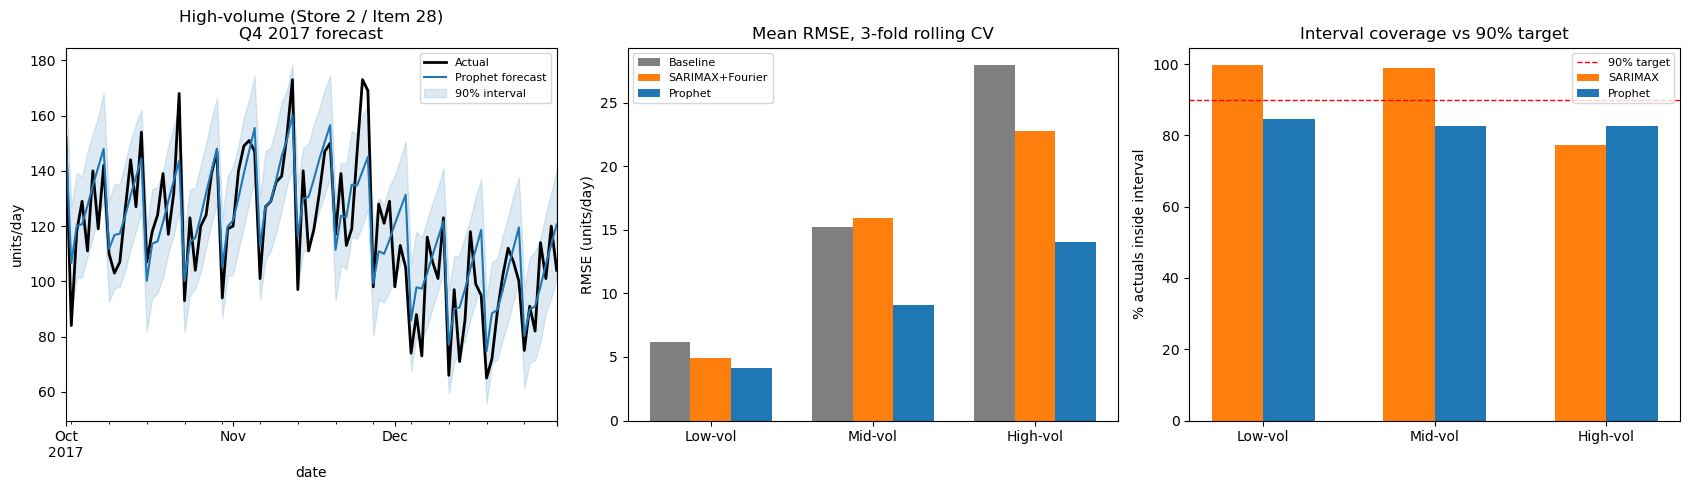

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. High-volume Q4 forecast with CI band (headline SKU)
ax = axes[0]
result_high_q4['actual'].plot(ax=ax, label='Actual', color='black', linewidth=2)
result_high_q4['prophet_pred'].plot(ax=ax, label='Prophet forecast', color='tab:blue')
ax.fill_between(result_high_q4['actual'].index, result_high_q4['prophet_lower'], result_high_q4['prophet_upper'],
                 color='tab:blue', alpha=0.15, label='90% interval')
ax.set_title(f"{SERIES['high']['label']}\nQ4 2017 forecast"); ax.legend(fontsize=8); ax.set_ylabel('units/day')

# 2. Mean RMSE by model, across volume tiers (rolling-origin average)
ax = axes[1]
x = np.arange(3); width = 0.25
tier_order = ['low','mid','high']; tier_labels=['Low-vol','Mid-vol','High-vol']
ax.bar(x-width, [agg_df.set_index('series').loc[SERIES[k]['label'],'baseline_rmse'] for k in tier_order], width, label='Baseline', color='gray')
ax.bar(x, [agg_df.set_index('series').loc[SERIES[k]['label'],'sarimax_rmse'] for k in tier_order], width, label='SARIMAX+Fourier', color='tab:orange')
ax.bar(x+width, [agg_df.set_index('series').loc[SERIES[k]['label'],'prophet_rmse'] for k in tier_order], width, label='Prophet', color='tab:blue')
ax.set_xticks(x); ax.set_xticklabels(tier_labels)
ax.set_title('Mean RMSE, 3-fold rolling CV'); ax.legend(fontsize=8); ax.set_ylabel('RMSE (units/day)')

# 3. CI coverage calibration vs 90% target
ax = axes[2]
ax.bar(x-0.15, [agg_df.set_index('series').loc[SERIES[k]['label'],'sarimax_coverage_pct'] for k in tier_order], 0.3, label='SARIMAX', color='tab:orange')
ax.bar(x+0.15, [agg_df.set_index('series').loc[SERIES[k]['label'],'prophet_coverage_pct'] for k in tier_order], 0.3, label='Prophet', color='tab:blue')
ax.axhline(90, color='red', linestyle='--', linewidth=1, label='90% target')
ax.set_xticks(x); ax.set_xticklabels(tier_labels)
ax.set_title('Interval coverage vs 90% target'); ax.legend(fontsize=8); ax.set_ylabel('% actuals inside interval')

plt.tight_layout()
plt.savefig('dashboard_snippet.png', dpi=150)
plt.show()


## 10. Key Findings (synthesis of Part A + Part B)

- **Prophet significantly outperforms both SARIMAX and the naive baseline, across all three volume tiers and all three rolling-origin folds** (Diebold-Mariano p < 0.001 in every case): a statistically supported result, not a single lucky split.
- **SARIMAX is not reliably better than doing nothing clever.** It's significantly better than baseline on 2 of 3 series, but statistically indistinguishable from baseline on the mid-volume series. Don't deploy it to a new SKU without validating per-product.
- **Both models' prediction intervals need calibration before production use.** Prophet's 90% interval only captured actuals ~80-85% of the time (too narrow / overconfident); SARIMAX's swung the other way on 2 of 3 series (98-100%, too wide to be useful for tight stocking decisions).
- **Q4 demand is a seasonal trough (~-20%), not a peak**, consistent across every tier tested. A generic "holiday increase" assumption would have driven the wrong stocking call here.
- **MAPE is unstable at low volume**; RMSE tells the truer story across tiers. The low-volume series has the highest MAPE but the lowest RMSE of any tier.

## 11. Recommended Actions (synthesis of Part A + Part B)

1. **Deploy Prophet (with US holiday regressors) as the forecasting model.** Its accuracy edge over both SARIMAX and the naive baseline is statistically significant (DM test, p < 0.001), not just numerically lower, and holds across three volume tiers and three separate forecast quarters.
2. **Do not deploy SARIMAX to a new SKU without per-product validation.** It is not statistically distinguishable from a naive seasonal baseline on mid-volume products (DM p ≈ 0.42) despite looking better on the first series tested.
3. **Widen Prophet's reported intervals before using them for safety stock.** Backtested coverage (~80-85%) ran below the nominal 90% target. A practical fix is to report the empirical backtest interval (actual ± ~1.2-1.3x the model's own interval half-width) rather than trusting the model's stated interval at face value.
4. **Plan Q4 stocking below Q3 levels, not above**, for these product tiers. Actual Q4 demand ran ~20% below Q3 across every series tested.
5. **Validate on a broader product sample before full catalog rollout.** Three series across the volume spectrum, each tested on three quarters, is enough to establish a directional, statistically supported model choice. It does not certify per-SKU accuracy across all 500 store-item combinations in the catalog.

## 12. Limitations

- Rolling-origin validation used 3 folds (one year of quarters) per series, not a multi-year rolling window. A longer validation history would strengthen the significance tests further.
- SARIMAX's `auto_arima` search grid was narrowed to keep 9 fits tractable; a wider search per-series might close some of its gap with Prophet, though it's unlikely to close a p<0.001 gap.
- This is a historical backtest against known outcomes (2017), used for model selection, not a live forecast into an unknown future quarter. Before acting on live numbers, refit Prophet on the most recent data and re-validate on the specific SKUs being stocked.
- Coverage/interval calibration was assessed empirically on the same 3 folds used for model comparison; a fully rigorous calibration study would use a separate held-out calibration set.